In [2]:
import matplotlib.pyplot as plt
import numpy as np
import itertools
import seaborn as sns
import math
import pandas as pd

import warnings


import Sardine

In [4]:
# load in the expression data from the multivariate normal checkerboard example
# make sure to modify where the the directory information where the data is stored
# alternatively, put the data files in the same directory as this script
expression_data = pd.read_csv("../data/checkerboard_simple_mvn_expr.csv",header=None).to_numpy()

dataset_size = int(expression_data.shape[0]/2)

# each expression matrix for the data of each condtion should be (# of spots) x (# of genes/features)
condition_1_samples = expression_data[0:dataset_size,:]
condition_2_samples = expression_data[dataset_size:,:]

In [6]:
meta_data = pd.read_csv("../data/checkerboard_simple_mvn_meta.csv", index_col=False)

# because this metadata has the same coordinates for both samples, divide in half
coordinates = meta_data[['x','y']].to_numpy()[0:dataset_size,:]

In [7]:
# coordinate matrix should be (# of spots) x 2
# in this case the same coordinate matrix can be used for both condition's data, in general not true
coordinates.shape

(1089, 2)

In [19]:
from importlib import reload
reload(Sardine)

<module 'Sardine' from '/Users/gh2161/Projects/spatial_anomaly_detection-main/scripts/Sardine.py'>

In [20]:
# run the hyperparameter sweep using Sardine

# parameter sets to sweep over
knn_param_set = [4,8,16,32]
beta_param_set = [10,25,50,100]

# array to store results
hyperparam_sweep_results_ourMethod = []

# create the KDTrees on the spatial coordinates. in this case both conditions have the same coordinates
KDTrees_for_replicates = Sardine.create_spatialKDTrees([coordinates], [coordinates])

# create an object to hold expression from both conditions
gene_feature_replicate_matrices = [condition_1_samples, condition_2_samples]

# run hyperparameter sweep
for knn_val in knn_param_set:
    for beta_val in beta_param_set:
        print("--------------------------------------------------------------------------")
        print(f"testing hyperparams: k for knn: {knn_val}, beta_param in MELD: {beta_val}")
        print("--------------------------------------------------------------------------")
        anomaly_scores_ourMethod = Sardine.calculate_anomaly_score(coordinates, 
                                                       KDTrees_for_replicates, 
                                                       gene_feature_replicate_matrices,
                                                                           num_replicates=1,
                                                                           neighborhood_size=30,
                                                                            knn = knn_val,
                                                                            beta=beta_val)  
        
        hyperparam_sweep_results_ourMethod.append(anomaly_scores_ourMethod)

testing hyperparams: k for knn: 4, beta_param in MELD: 10
--------------------------------------------------------------------------
Building graph on 2178 samples and 100 features.
Calculating graph and diffusion operator...
  Calculating KNN search...
  Calculated KNN search in 0.03 seconds.
  Calculating affinities...
  Calculated affinities in 0.04 seconds.
Calculated graph and diffusion operator in 0.08 seconds.
testing hyperparams: k for knn: 4, beta_param in MELD: 25
--------------------------------------------------------------------------
Building graph on 2178 samples and 100 features.
Calculating graph and diffusion operator...
  Calculating KNN search...
  Calculated KNN search in 0.01 seconds.
  Calculating affinities...
  Calculated affinities in 0.04 seconds.
Calculated graph and diffusion operator in 0.06 seconds.
testing hyperparams: k for knn: 4, beta_param in MELD: 50
--------------------------------------------------------------------------
Building graph on 2178 sa

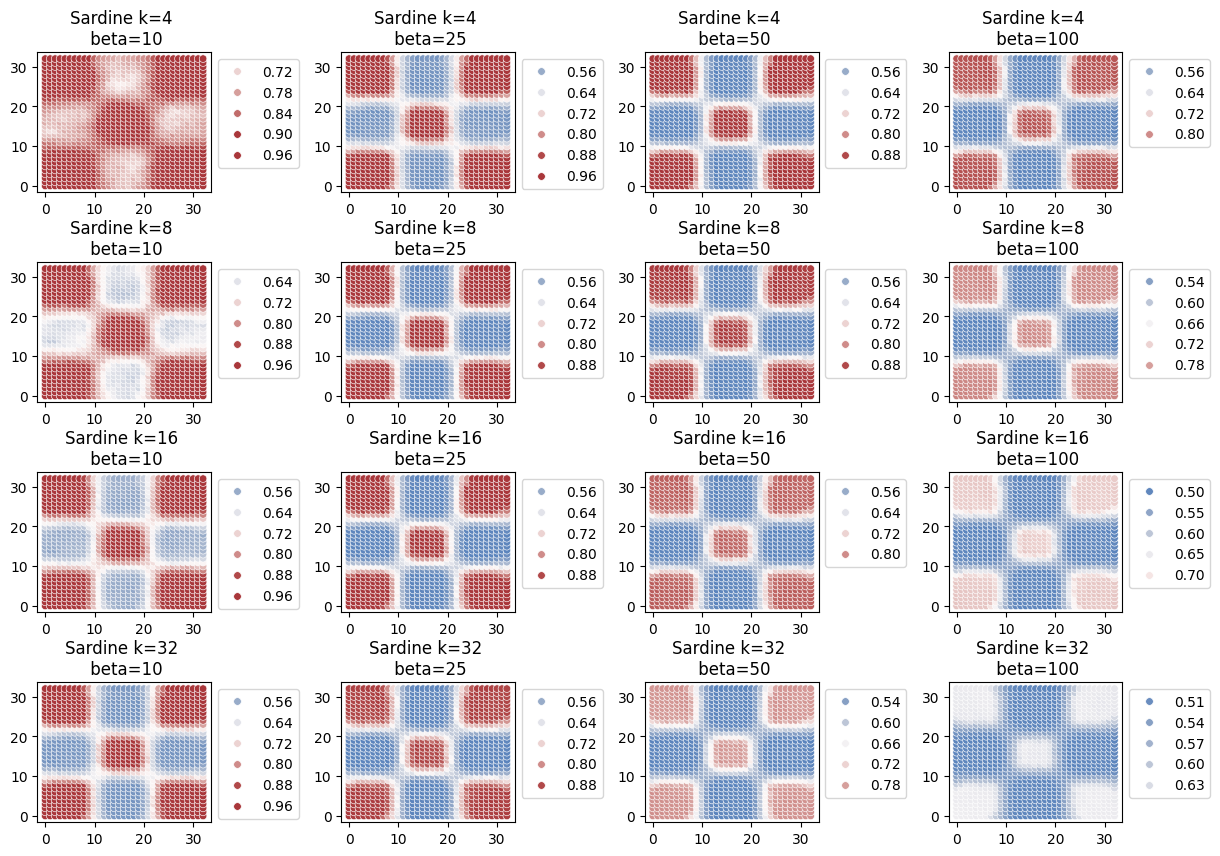

In [24]:
# plot the corresponding result
fig, axes = plt.subplots(nrows=len(knn_param_set), ncols=len(beta_param_set), figsize=(14,10))

counter=0
for i in range(len(knn_param_set)):
    for j in range(len(beta_param_set)):
        sns.scatterplot(x=coordinates[:,0], 
                y=coordinates[:,1], 
                hue=np.asarray(hyperparam_sweep_results_ourMethod[counter]), 
                s= 30,
                palette="vlag",
                legend=True,
                hue_norm=(0.45, 0.9),
                ax=axes[i][j])
        title = f"Sardine k={knn_param_set[i]} \n beta={beta_param_set[j]}"
        axes[i][j].set_title(title)
        sns.move_legend(axes[i][j], "upper left", bbox_to_anchor=(1, 1))
        counter+=1
fig.subplots_adjust(hspace=0.5)
fig.subplots_adjust(wspace=0.75)